In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('House Price India.csv')

In [3]:
data.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [5]:
corr = data.corr()
print(corr["Price"].sort_values(ascending=False))

Price                                    1.000000
living area                              0.712276
grade of the house                       0.671805
Area of the house(excluding basement)    0.615179
living_area_renov                        0.585021
number of bathrooms                      0.532031
number of views                          0.394954
Area of the basement                     0.330499
number of bedrooms                       0.308165
Lattitude                                0.297570
waterfront present                       0.263943
number of floors                         0.262649
Renovation Year                          0.133362
lot area                                 0.082117
lot_area_renov                           0.075697
Built Year                               0.050936
condition of the house                   0.040609
Longitude                                0.024807
Number of schools nearby                 0.009904
Distance from the airport                0.004074


In [6]:
stats = data["Price"].describe().reset_index() 
stats["Price"] = round(stats["Price"], 2)

In [7]:
stats

,index,Price
0,count,14619.00
1,mean,538806.28
2,std,367229.36
3,min,78000.00
4,25%,320000.00
5,50%,450000.00
6,75%,645000.00
7,max,7700000.00


In [8]:
data.isna().sum().sum()

np.int64(0)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

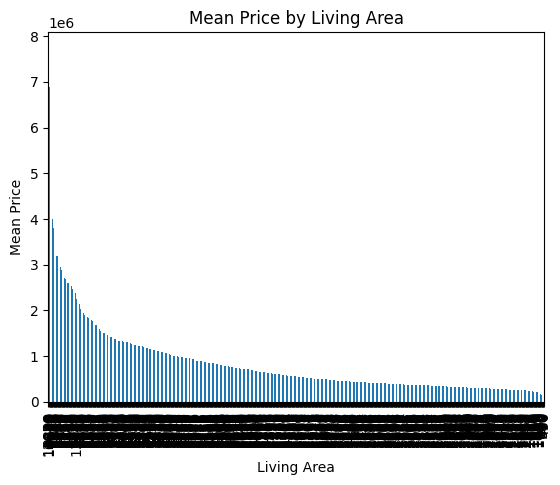

In [11]:
data.groupby("living area")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Mean Price by Living Area")
plt.ylabel("Mean Price")
plt.xlabel("Living Area")
plt.show()

In [12]:
x = data[[ "living area","grade of the house","Area of the house(excluding basement)","living_area_renov","number of bathrooms"]]
y = data[["Price"]]

In [13]:
x

,living area,grade of the house,Area of the house(excluding basement),living_area_renov,number of bathrooms
0,2920,8,1910,2470,2.50
1,2910,8,2910,2940,2.75
2,3310,9,3310,3350,2.50
3,2710,8,1880,2060,2.00
4,2600,9,1700,2380,2.50
...,...,...,...,...,...
14614,1556,7,1556,2250,1.50
14615,1680,7,1680,1540,2.00
14616,1070,6,1070,1130,1.00
14617,1030,6,1030,1420,1.00


In [14]:
y

,Price
0,1400000
1,1200000
2,838000
3,805000
4,790000
...,...
14614,221700
14615,219200
14616,209000
14617,205000


In [15]:
data.shape

(14619, 23)

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,)

In [17]:
x

,living area,grade of the house,Area of the house(excluding basement),living_area_renov,number of bathrooms
0,2920,8,1910,2470,2.50
1,2910,8,2910,2940,2.75
2,3310,9,3310,3350,2.50
3,2710,8,1880,2060,2.00
4,2600,9,1700,2380,2.50
...,...,...,...,...,...
14614,1556,7,1556,2250,1.50
14615,1680,7,1680,1540,2.00
14616,1070,6,1070,1130,1.00
14617,1030,6,1030,1420,1.00


In [18]:
x_train.shape

(11695, 5)

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
from sklearn.tree import DecisionTreeRegressor
param_grid = {
    "criterion": ["mse", "friedman_mse", "mae"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10, 20, 30,40,50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [21]:
tree_model = DecisionTreeRegressor()

In [22]:
grid_tree = GridSearchCV(estimator=tree_model, param_grid = param_grid)

In [23]:
grid_tree.fit(x_train, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1080 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.p

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['mse', 'friedman_mse', 'mae'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [24]:
grid_tree.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'splitter': 'random'}

In [25]:
tree_preds = grid_tree.predict(x_test)

In [26]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mean_squared_error(y_test, tree_preds)

55054134788.02275

In [27]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

In [28]:
lr.fit(x_train, y_train)

LinearRegression()

In [29]:
predslr= lr.predict(x_test)

In [30]:
mean_squared_error(y_test, predslr)

54843421778.84014

In [31]:
mean_absolute_error(y_test, predslr)

159935.00849936373

In [32]:
from sklearn.ensemble import RandomForestRegressor
rfrmodel = RandomForestRegressor()

In [33]:
param_gridrfr={
  "max_depth": [5,10,15],
  "n_estimators": [2,3,4,5,6,7,8,9,10]
}

In [34]:
gridrfr =GridSearchCV(rfrmodel, param_gridrfr)

In [35]:
gridrfr.fit(x_train, y_train.values.ravel())

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [36]:
gridrfr.best_params_

{'max_depth': 10, 'n_estimators': 10}

In [37]:
rfrpredictions = gridrfr.predict(x_test)

In [38]:
mean_absolute_error(y_test, rfrpredictions)

145409.1606186633

In [39]:
import joblib
joblib.dump(gridrfr, "house_price_predictor_model.pkl")

['house_price_predictor_model.pkl']

In [40]:
x.columns

Index(['living area', 'grade of the house',
       'Area of the house(excluding basement)', 'living_area_renov',
       'number of bathrooms'],
      dtype='object')